Data shape: (1100, 21)

Stress level distribution:
stress_level
0    373
1    358
2    369
Name: count, dtype: int64

Model Parameters:
m (binomial trials): 2 (consistent for all observations)
K (Bernstein degree): 6
Stress level range: 0 to 2
Number of covariates (including intercept): 21
Training set: (550, 21), Test set: (550, 21)
BERNSTEIN-BINOMIAL vs BETA-BINOMIAL COMPARISON

1. Training Bernstein-Binomial Regression...
Optimizing Bernstein-Binomial regression...
✓ Bernstein-Binomial regression optimized successfully!
  Final negative log-likelihood: 0.446490
  Iterations: 125

2. Training Beta-Binomial Regression...
✓ Beta-Binomial regression optimized successfully!

INFORMATION CRITERIA COMPARISON

Bernstein-Binomial:
  Log-Likelihood: -226.72
  Parameters: 33
  AIC: 519.45
  BIC: 661.68

Beta-Binomial:
  Log-Likelihood: -279.84
  Parameters: 21
  AIC: 601.68
  BIC: 692.19

PREDICTIVE PERFORMANCE ON TEST SET

Bernstein-Binomial:
  MSE: 0.1332
  MAE: 0.1377
  R²: 0.8030
  Accurac

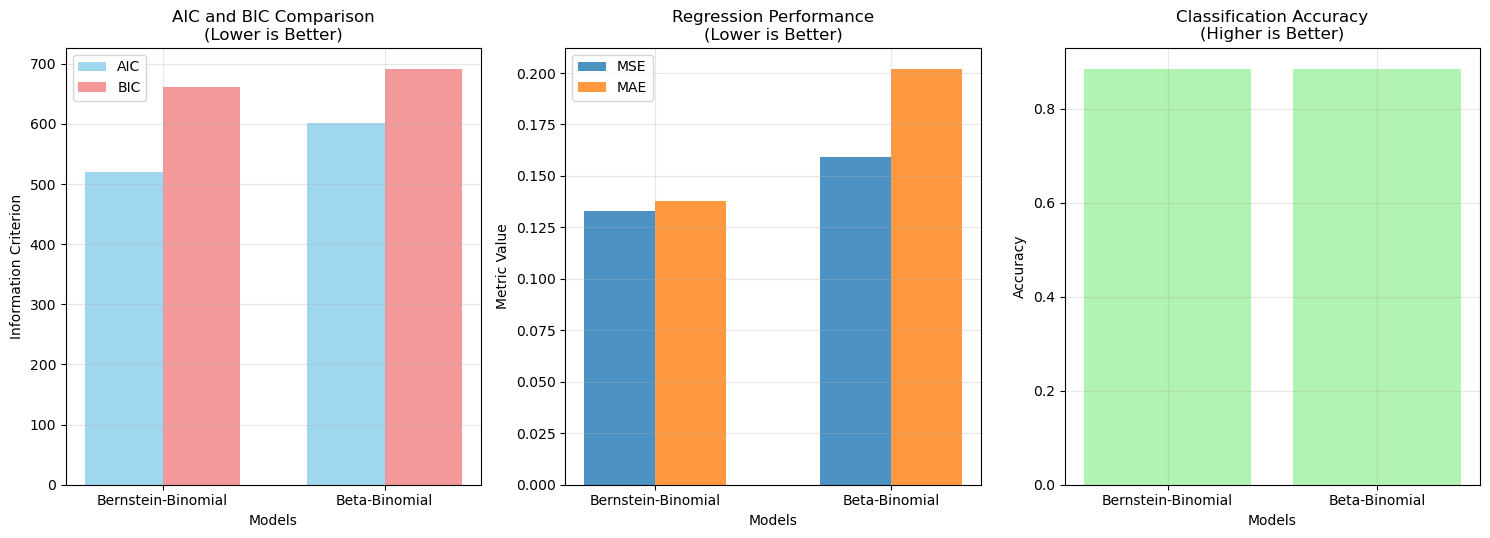

In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import comb, gammaln, logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Read data
data = pd.read_csv('StressLevelDataset.csv')

# Focus on stress_level analysis
print("Data shape:", data.shape)
print("\nStress level distribution:")
stress_dist = data['stress_level'].value_counts().sort_index()
print(stress_dist)

# Define features and target
features = [col for col in data.columns if col != 'stress_level']
X = data[features].values
y = data['stress_level'].values.astype(int)

# Consistent parameters for stress_level (0,1,2)
m = 2  # Binomial trials - consistent for all observations
K = 6  # Bernstein polynomial degree

print(f"\nModel Parameters:")
print(f"m (binomial trials): {m} (consistent for all observations)")
print(f"K (Bernstein degree): {K}")
print(f"Stress level range: {y.min()} to {y.max()}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
Z = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled])
p = Z.shape[1]

print(f"Number of covariates (including intercept): {p}")

# Split data
Z_train, Z_test, y_train, y_test = train_test_split(Z, y, test_size=0.5, random_state=42)
n_train, n_test = Z_train.shape[0], Z_test.shape[0]

print(f"Training set: {Z_train.shape}, Test set: {Z_test.shape}")

class BernsteinBinomialRegression:
    def __init__(self, K=3, m=3):
        self.K = K
        self.m = m  # Consistent m for all observations
        self.alpha = None
        self.phi = None
        self.beta = None
        self.log_likelihood = None
        self.n_params = None
        
    def _compute_eta(self, Z, alpha, phi, beta):
        """Compute eta_ik = alpha_k + phi_k * (Z_i^T beta)"""
        n = Z.shape[0]
        Z_beta = Z @ beta
        eta = np.zeros((n, self.K + 1))
        
        # k = 0: alpha_0 = 0, phi_0 = 1
        eta[:, 0] = 0 + 1.0 * Z_beta
        
        # k = 1,...,K
        for k in range(1, self.K + 1):
            eta[:, k] = alpha[k-1] + phi[k-1] * Z_beta
            
        return eta
    
    def _compute_lambda(self, eta):
        """Compute lambda_ik = exp(eta_ik) / sum_l exp(eta_il)"""
        max_eta = np.max(eta, axis=1, keepdims=True)
        exp_eta = np.exp(eta - max_eta)
        lambda_mat = exp_eta / np.sum(exp_eta, axis=1, keepdims=True)
        return np.clip(lambda_mat, 1e-10, 1.0)
    
    def _bernstein_basis(self, p, y_obs):
        """Bernstein basis with consistent m"""
        return comb(self.m, y_obs) * (p ** y_obs) * ((1 - p) ** (self.m - y_obs))
    
    def _log_likelihood(self, params, Z, y):
        """Log-likelihood function"""
        n, p = Z.shape
        K = self.K
        
        alpha = params[:K]
        phi = params[K:2*K]
        beta = params[2*K:2*K+p]
        
        # Ensure phi are positive
        phi_pos = np.exp(phi)
        
        # Compute eta and lambda
        eta = self._compute_eta(Z, alpha, phi_pos, beta)
        lambda_mat = self._compute_lambda(eta)
        
        log_likelihood = 0.0
        for i in range(n):
            mixture_prob = 0.0
            for k in range(K + 1):
                p_val = k / K  # Discrete probability points
                bernstein_val = self._bernstein_basis(p_val, y[i])
                mixture_prob += lambda_mat[i, k] * bernstein_val
            
            if mixture_prob > 1e-100:
                log_likelihood += np.log(mixture_prob)
        
        return log_likelihood
    
    def _negative_log_likelihood(self, params, Z, y):
        """Negative log-likelihood for optimization"""
        log_likelihood = self._log_likelihood(params, Z, y)
        regularization = 0.001 * np.sum(params**2)
        return -(log_likelihood / len(y)) + regularization
    
    def fit(self, Z, y, max_iter=1000):
        """Fit the model"""
        n, p = Z.shape
        K = self.K
        
        # Initialize parameters
        np.random.seed(42)
        alpha_init = np.random.normal(0, 0.1, K)
        phi_init = np.log(np.ones(K))  # Start with phi = 1 in log space
        beta_init = np.random.normal(0, 0.1, p)
        
        initial_params = np.concatenate([alpha_init, phi_init, beta_init])
        bounds = [(-5, 5)] * (K + K + p)
        
        print("Optimizing Bernstein-Binomial regression...")
        
        result = minimize(self._negative_log_likelihood, initial_params,
                         args=(Z, y), method='L-BFGS-B', bounds=bounds,
                         options={'maxiter': max_iter, 'ftol': 1e-8, 'gtol': 1e-8})
        
        # Store parameters
        self.alpha = result.x[:K]
        self.phi = np.exp(result.x[K:2*K])  # Transform back to positive
        self.beta = result.x[2*K:2*K+p]
        self.optimization_result = result
        
        # Calculate information criteria
        self.log_likelihood = self._log_likelihood(result.x, Z, y)
        self.n_params = K + K + p  # alpha + phi + beta
        
        if result.success:
            print("✓ Bernstein-Binomial regression optimized successfully!")
            print(f"  Final negative log-likelihood: {result.fun:.6f}")
            print(f"  Iterations: {result.nit}")
        else:
            print(f"⚠ Optimization message: {result.message}")
        
        return result
    
    def calculate_aic_bic(self, n_samples):
        """Calculate AIC and BIC"""
        if self.log_likelihood is None:
            return None, None
        
        aic = 2 * self.n_params - 2 * self.log_likelihood
        bic = np.log(n_samples) * self.n_params - 2 * self.log_likelihood
        return aic, bic
    
    def predict_proba(self, Z):
        """Predict probability for each stress level"""
        eta = self._compute_eta(Z, self.alpha, self.phi, self.beta)
        lambda_mat = self._compute_lambda(eta)
        
        # Predict probability for each level (0,1,2)
        prob_matrix = np.zeros((Z.shape[0], self.m + 1))
        for i in range(Z.shape[0]):
            for stress_level in range(self.m + 1):
                prob = 0.0
                for k in range(self.K + 1):
                    p_val = k / self.K
                    bernstein_val = self._bernstein_basis(p_val, stress_level)
                    prob += lambda_mat[i, k] * bernstein_val
                prob_matrix[i, stress_level] = prob
        
        # Normalize probabilities
        return prob_matrix / np.sum(prob_matrix, axis=1, keepdims=True)
    
    def predict(self, Z):
        """Predict discrete stress level"""
        prob_matrix = self.predict_proba(Z)
        return np.argmax(prob_matrix, axis=1)
    
    def predict_continuous(self, Z):
        """Predict continuous value for regression metrics"""
        prob_matrix = self.predict_proba(Z)
        return prob_matrix @ np.arange(self.m + 1)

class BetaBinomialRegression:
    def __init__(self, m=2):
        self.m = m  # Consistent m for all observations
        self.coefficients = None
        self.log_likelihood = None
        self.n_params = None
        
    def _log_likelihood(self, params, Z, y):
        """Beta-Binomial log-likelihood"""
        n, p = Z.shape
        
        logit_p = Z @ params
        p_vals = 1 / (1 + np.exp(-logit_p))
        p_vals = np.clip(p_vals, 0.001, 0.999)
        
        # Beta-Binomial with fixed dispersion
        dispersion = 5.0
        alpha = p_vals * dispersion
        beta = (1 - p_vals) * dispersion
        
        log_likelihood = 0.0
        for i in range(n):
            log_prob = (gammaln(self.m + 1) - gammaln(y[i] + 1) - gammaln(self.m - y[i] + 1) +
                       gammaln(y[i] + alpha[i]) + gammaln(self.m - y[i] + beta[i]) - 
                       gammaln(self.m + alpha[i] + beta[i]) +
                       gammaln(alpha[i] + beta[i]) - gammaln(alpha[i]) - gammaln(beta[i]))
            
            if np.isfinite(log_prob):
                log_likelihood += log_prob
        
        return log_likelihood
    
    def _negative_log_likelihood(self, params, Z, y):
        """Negative log-likelihood for optimization"""
        log_likelihood = self._log_likelihood(params, Z, y)
        regularization = 0.01 * np.sum(params**2)
        return -(log_likelihood / len(y)) + regularization
    
    def fit(self, Z, y):
        """Fit the model"""
        p = Z.shape[1]
        initial_params = np.zeros(p)
        
        result = minimize(self._negative_log_likelihood, initial_params,
                         args=(Z, y), method='L-BFGS-B',
                         options={'maxiter': 500, 'ftol': 1e-8})
        
        self.coefficients = result.x
        self.optimization_result = result
        
        # Calculate information criteria
        self.log_likelihood = self._log_likelihood(result.x, Z, y)
        self.n_params = p
        
        if result.success:
            print("✓ Beta-Binomial regression optimized successfully!")
        else:
            print(f"⚠ Optimization message: {result.message}")
            
        return result
    
    def calculate_aic_bic(self, n_samples):
        """Calculate AIC and BIC"""
        if self.log_likelihood is None:
            return None, None
        
        aic = 2 * self.n_params - 2 * self.log_likelihood
        bic = np.log(n_samples) * self.n_params - 2 * self.log_likelihood
        return aic, bic
    
    def predict(self, Z):
        """Predict discrete stress level"""
        logit_p = Z @ self.coefficients
        p_vals = 1 / (1 + np.exp(-logit_p))
        return (p_vals * self.m).round().astype(int)
    
    def predict_continuous(self, Z):
        """Predict continuous value for regression metrics"""
        logit_p = Z @ self.coefficients
        p_vals = 1 / (1 + np.exp(-logit_p))
        return p_vals * self.m

print("="*70)
print("BERNSTEIN-BINOMIAL vs BETA-BINOMIAL COMPARISON")
print("="*70)

models = {}

# Bernstein-Binomial
print("\n1. Training Bernstein-Binomial Regression...")
models['Bernstein-Binomial'] = BernsteinBinomialRegression(K=K, m=m)
models['Bernstein-Binomial'].fit(Z_train, y_train)

print("\n2. Training Beta-Binomial Regression...")
models['Beta-Binomial'] = BetaBinomialRegression(m=m)
models['Beta-Binomial'].fit(Z_train, y_train)

print("\n" + "="*70)
print("INFORMATION CRITERIA COMPARISON")
print("="*70)

info_criteria = {}
for name, model in models.items():
    aic, bic = model.calculate_aic_bic(n_train)
    n_params = model.n_params
    log_likelihood = model.log_likelihood
    
    if aic is not None and bic is not None:
        info_criteria[name] = {
            'AIC': aic, 'BIC': bic, 
            'Log-Likelihood': log_likelihood, 'Parameters': n_params
        }
        
        print(f"\n{name}:")
        print(f"  Log-Likelihood: {log_likelihood:.2f}")
        print(f"  Parameters: {n_params}")
        print(f"  AIC: {aic:.2f}")
        print(f"  BIC: {bic:.2f}")

# Evaluate predictive performance
def evaluate_model(y_true, y_pred, y_pred_continuous, model_name):
    """Comprehensive model evaluation"""
    mse = mean_squared_error(y_true, y_pred_continuous)
    mae = mean_absolute_error(y_true, y_pred_continuous)
    r2 = r2_score(y_true, y_pred_continuous)
    accuracy = accuracy_score(y_true, y_pred)
    
    level_accuracy = {}
    for level in np.unique(y_true):
        mask = y_true == level
        if np.sum(mask) > 0:
            level_accuracy[level] = accuracy_score(y_true[mask], y_pred[mask])
    
    return {
        'MSE': mse, 'MAE': mae, 'R2': r2, 'Accuracy': accuracy,
        'Level_Accuracy': level_accuracy
    }

print("\n" + "="*70)
print("PREDICTIVE PERFORMANCE ON TEST SET")
print("="*70)

performance_results = {}
for name, model in models.items():
    y_pred = model.predict(Z_test)
    y_pred_cont = model.predict_continuous(Z_test)
    performance_results[name] = evaluate_model(y_test, y_pred, y_pred_cont, name)
    
    print(f"\n{name}:")
    print(f"  MSE: {performance_results[name]['MSE']:.4f}")
    print(f"  MAE: {performance_results[name]['MAE']:.4f}")
    print(f"  R²: {performance_results[name]['R2']:.4f}")
    print(f"  Accuracy: {performance_results[name]['Accuracy']:.4f}")
    
    print("  Class-wise Accuracy:")
    for level, acc in performance_results[name]['Level_Accuracy'].items():
        print(f"    Level {level}: {acc:.4f}")

comparison_data = []
for name in models.keys():
    if name in info_criteria and name in performance_results:
        row = {
            'Model': name,
            'Log-Likelihood': info_criteria[name]['Log-Likelihood'],
            'Parameters': info_criteria[name]['Parameters'],
            'AIC': info_criteria[name]['AIC'],
            'BIC': info_criteria[name]['BIC'],
            'MSE': performance_results[name]['MSE'],
            'MAE': performance_results[name]['MAE'],
            'R2': performance_results[name]['R2'],
            'Accuracy': performance_results[name]['Accuracy']
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON")
print("="*70)
print(comparison_df.round(4))

best_models = {
    'AIC': min(info_criteria, key=lambda x: info_criteria[x]['AIC']),
    'BIC': min(info_criteria, key=lambda x: info_criteria[x]['BIC']),
    'MSE': min(performance_results, key=lambda x: performance_results[x]['MSE']),
    'Accuracy': max(performance_results, key=lambda x: performance_results[x]['Accuracy']),
}

print("\n" + "="*70)
print("BEST MODEL BY DIFFERENT CRITERIA")
print("="*70)
for criterion, best_model in best_models.items():
    if criterion in ['AIC', 'BIC']:
        value = info_criteria[best_model][criterion]
    else:
        value = performance_results[best_model][criterion]
    print(f"{criterion}: {best_model} ({value:.4f})")

# Visualization
plt.figure(figsize=(15, 10))

# 1. AIC/BIC comparison
plt.subplot(2, 3, 1)
models_list = list(info_criteria.keys())
aic_values = [info_criteria[model]['AIC'] for model in models_list]
bic_values = [info_criteria[model]['BIC'] for model in models_list]

x = np.arange(len(models_list))
width = 0.35
plt.bar(x - width/2, aic_values, width, label='AIC', alpha=0.8, color='skyblue')
plt.bar(x + width/2, bic_values, width, label='BIC', alpha=0.8, color='lightcoral')
plt.xlabel('Models')
plt.ylabel('Information Criterion')
plt.title('AIC and BIC Comparison\n(Lower is Better)')
plt.xticks(x, models_list)
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Performance metrics
plt.subplot(2, 3, 2)
metrics = ['MSE', 'MAE']
x = np.arange(len(models_list))
for i, metric in enumerate(metrics):
    values = [performance_results[model][metric] for model in models_list]
    plt.bar(x + i*0.3, values, 0.3, label=metric, alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Metric Value')
plt.title('Regression Performance\n(Lower is Better)')
plt.xticks(x + 0.15, models_list)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Accuracy comparison
plt.subplot(2, 3, 3)
accuracies = [performance_results[model]['Accuracy'] for model in models_list]
plt.bar(models_list, accuracies, alpha=0.7, color='lightgreen')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy\n(Higher is Better)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()